In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn import metrics

from data_preprocessing import preprocess_normal


In [2]:
xtrain_raw, xval, xtest, ytrain_raw, yval, ytest, scaler, le = preprocess_normal("datasets/normal")

xtrain = np.concatenate([xtrain_raw, xval])
ytrain = np.concatenate([ytrain_raw, yval])

[Normal] classes：['downstairs', 'jump', 'run', 'upstairs', 'walk'], train：3925, val：1309, test：1309


In [3]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [9, 12, 15, 20],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced'],
}

dt_params = {
    'criterion': ['gini'],
    'class_weight': ['balanced'],
    'max_depth': [10, 20, 30, 40],
    'min_samples_leaf': [1, 2, 3, 5, 10],
}


In [4]:
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=10, scoring='accuracy', n_jobs=-1)
rf_grid.fit(xtrain, ytrain)
print("RF best params:", rf_grid.best_params_)
print("RF best CV acc:", rf_grid.best_score_)

best_rf = rf_grid.best_estimator_
ypred_rf = best_rf.predict(xtest)
print("\nRF train acc:", accuracy_score(ytrain, best_rf.predict(xtrain)))
print("RF test  acc:", accuracy_score(ytest, ypred_rf))
print(classification_report(ytest, ypred_rf, target_names=list(le.classes_)))


RF best params: {'class_weight': 'balanced', 'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 300}
RF best CV acc: 0.9512785894647731

RF train acc: 1.0
RF test  acc: 0.961038961038961
              precision    recall  f1-score   support

  downstairs       0.94      0.90      0.92       186
        jump       0.98      0.98      0.98       234
         run       0.95      0.98      0.96       250
    upstairs       0.94      0.94      0.94       246
        walk       0.98      0.98      0.98       393

    accuracy                           0.96      1309
   macro avg       0.96      0.96      0.96      1309
weighted avg       0.96      0.96      0.96      1309



In [5]:
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=10, scoring='accuracy', n_jobs=-1)
dt_grid.fit(xtrain, ytrain)
print("DT best params:", dt_grid.best_params_)
print("DT best CV acc:", dt_grid.best_score_)

best_dt = dt_grid.best_estimator_
ypred_dt = best_dt.predict(xtest)
print("\nDT train acc:", accuracy_score(ytrain, best_dt.predict(xtrain)))
print("DT test  acc:", accuracy_score(ytest, ypred_dt))
print(classification_report(ytest, ypred_dt, target_names=list(le.classes_)))


DT best params: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 1}
DT best CV acc: 0.9247219505787225

DT train acc: 0.9986625907527703
DT test  acc: 0.93048128342246
              precision    recall  f1-score   support

  downstairs       0.86      0.85      0.86       186
        jump       0.98      0.97      0.97       234
         run       0.93      0.93      0.93       250
    upstairs       0.88      0.93      0.90       246
        walk       0.97      0.95      0.96       393

    accuracy                           0.93      1309
   macro avg       0.92      0.92      0.92      1309
weighted avg       0.93      0.93      0.93      1309



In [6]:
labels = list(le.classes_)
matrix_rf = metrics.confusion_matrix(ytest, ypred_rf)
matrix_dt = metrics.confusion_matrix(ytest, ypred_dt)


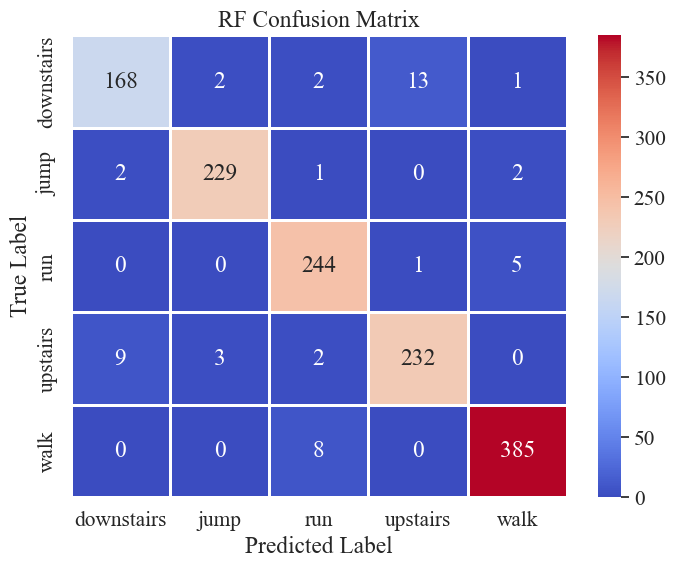

In [7]:
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid", font='Times New Roman', font_scale=1.4)
sns.heatmap(matrix_rf,
            cmap="coolwarm",
            linecolor='white',
            linewidths=1,
            xticklabels=labels,
            yticklabels=labels,
            annot=True,
            fmt="d")
plt.title("RF Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.savefig('./image/rf_NormalGait_CM.jpg', dpi=500, bbox_inches='tight')
plt.show()


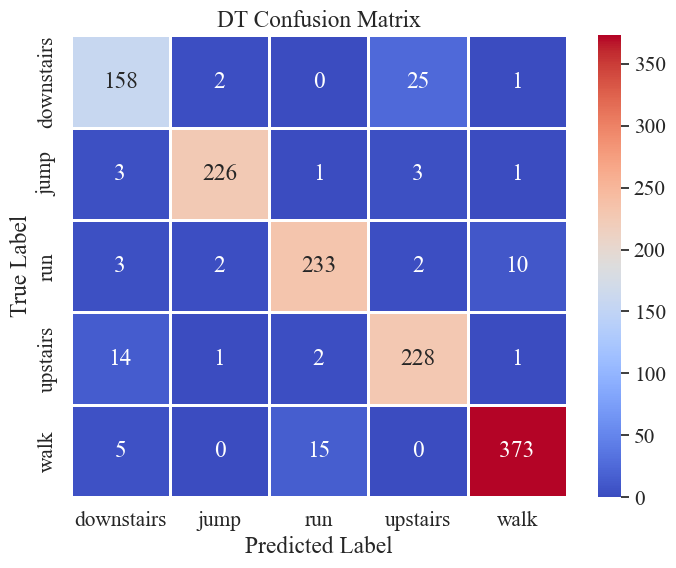

In [8]:
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid", font='Times New Roman', font_scale=1.4)
sns.heatmap(matrix_dt,
            cmap="coolwarm",
            linecolor='white',
            linewidths=1,
            xticklabels=labels,
            yticklabels=labels,
            annot=True,
            fmt="d")
plt.title("DT Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.savefig('./image/dt_NormalGait_CM.jpg', dpi=500, bbox_inches='tight')
plt.show()
